## ANALISI DEL DATASET

### Importazione librerie e caricamento del dataset
Importiamo le librerie necessarie e carichiamo il dataset con un controllo e restituendo un errore in caso non venga trovato

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

pd.set_option('display.max_columns', None)

file_path = 'datasets/raw_dataset.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Caricamento del dataset avvenuto con successo! Dimensioni: {df.shape}")
else:
    print("ERRORE: Il dataset non è stato trovato.")

Caricamento del dataset avvenuto con successo! Dimensioni: (4424, 35)


### Controlliamo con che tipi di dati andremo a lavorare
Usando df.info() notiamo che la maggior parte dei dati sono di tipo int, per capire a cosa si riferiscono questi dati useremo la leggenda sulla pagina del dataset di **[UCI](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)**

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

### Controlliamo che non ci siano missing values o duplicati, se ne troviamo li rimuoviamo
Facendo un rapido controllo tramite le funzioni df.isnull() e df.duplicated() notiamo che il dataset non ha missing values o duplicati

In [3]:
#Controllo dei valori nulli
print(f"Valori mancanti per colonna: {df.isnull().sum().sum()}")

#Controllo dei duplicati
print(f"Righe duplicate trovate: {df.duplicated().sum()}")

#Se ci sono duplicati, li rimuoviamo
df = df.drop_duplicates()

Valori mancanti per colonna: 0
Righe duplicate trovate: 0


### Generiamo grafico e percentuali per analizzare la distribuzione degli studenti per quanto riguarda il target
Generando un grafico a torta con le relative percentuali vediamo che il dataset è composto per quasi la metà da laureati (49,9%) i dropout rappresentano all'incirca 1/3 della torta (32,1%) e la classe degli studenti ancora iscritti è la meno numerosa (17,9%). Possiamo quindi procedere all'esclusione della categoria 'Enrolled'. Questa scelta è motivata dal fatto che tale classe rappresenta una situazione temporanea e non definitiva: non sappiamo se questi studenti porteranno a termine gli studi o abbandoneranno in futuro. Rimuovendoli trasformiamo il problema in una classificazione binaria netta, permettendo al modello di concentrarsi esclusivamente sulle caratteristiche distintive che separano chi ha già concluso con successo il percorso (Graduate) da chi lo ha interrotto (Dropout) 

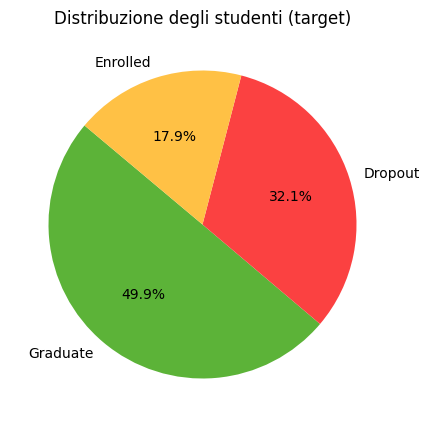

In [4]:
counts = df['Target'].value_counts()
labels = counts.index

plt.figure(figsize=(5,5))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    # colors=('#499d33', '#cc3018', '#cd680e')
    colors=('#5CB338', '#FB4141', '#FFC145')
)

plt.title('Distribuzione degli studenti (target)')
plt.show()

### Creiamo una matrice di correlazione (heatmap) per analizzare le correlazioni tra le variabili
Poiché il Target originale è di tipo testuale, creiamo una variabile temporanea numerica mappando le classi (Dropout: 0, Enrolled: 1, Graduate: 2). Questa analisi ci permette di individuare i principali predittori del successo universitario e di scovare eventuali multicollinearità che potrebbero risultare ridondanti durante la fase di addestramento del modello.

Dall'analisi di questa matrice di correlazione sono emersi alcuni segnali interessanti. Come prevedibile notiamo che il successo e l'abbandono di uno studente risultano fortemente associati alle performance accademiche, in particolare al numero di unità curriculari approvate e ai voti medi ottenuti nei due semestri. 

Osserviamo inoltre una forte multicollinearità tra le variabili relative alle unità curriculari (enrolled, evaluations, approved, grade, credited, without evaluations), che misurano aspetti strettamente connessi dello stesso fenomeno, ossia il rendimento accademico. considereremo questa ridondanza nella fase di pulizia dei dati, valutandone l’eliminazione o l’aggregazione delle variabili meno informative per evitare instabilità nei modelli.

Emerge anche una forte relazione tra la regolarità dei pagamenti (Tuition fees up to date) e il successo accademico. Tuttavia si ritiene superfluo un approfondimento su questa variabile perché la regolarità amministrativa è una condizione necessaria per la laurea, rendendo il dato una conseguenza logica del target piuttosto che un fattore predittivo utile per un intervento preventivo. 

Al contrario, fattori come l'età all'iscrizione (Age at enrollment) mostrano una correlazione negativa, suggerendo che probabilmente un'età più avanzata possa rappresentare una sfida ulteriore per il completamento degli studi che andremo ad analizzare successivamente. 

La matrice evidenzia inoltre una forte ridondanza tra alcune colonne, come quella tra la nazionalità e lo status di studente internazionale, poiché queste variabili veicolano la medesima informazione, potremo snellire il dataset eliminando la colonna superflua nella fase di cleaning. 

Infine, si osserva che alcune variabili macroeconomiche (Unemployment rate, Inflation rate, GDP) presentano correlazioni deboli con il target e con le altre feature; tali variabili potranno essere valutate per un’eventuale esclusione al fine di ridurre il rumore nel modello.

Osserviamo che alcune variabili quali Father’s qualification, Mother’s qualification, Father’s occupation e Mother’s occupation, sono codificate come valori interi che corrispondono a categorie descritte nella legenda del dataset UCI. La correlazione calcolata su queste colonne è quindi da considerarsi puramente esplorativa

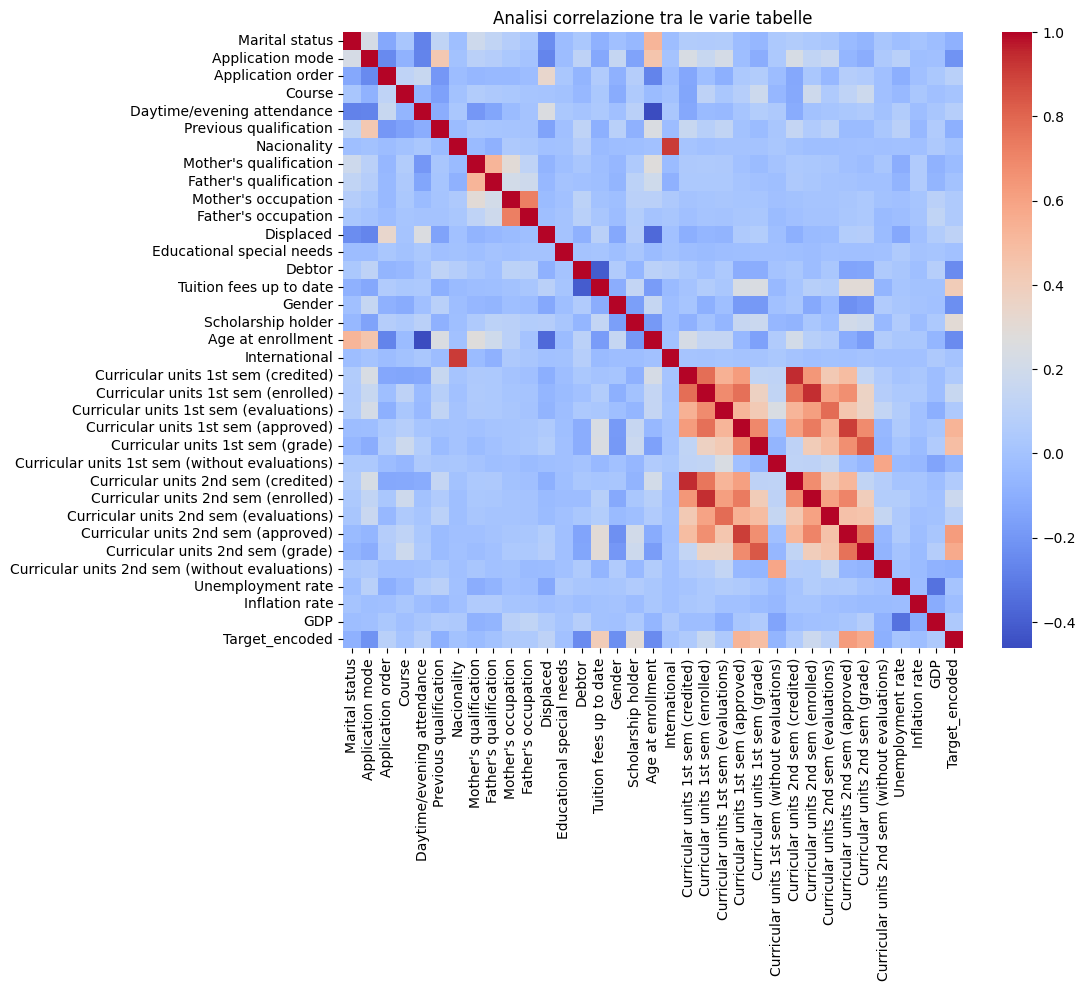

In [5]:
temp_df = df.copy()
temp_df['Target_encoded'] = temp_df['Target'].map({
    'Dropout': 0, 
    'Enrolled': 1, 
    'Graduate': 2})

plt.figure(figsize=(10, 8))
sns.heatmap(temp_df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Analisi correlazione tra le varie tabelle")
plt.show()

### Generiamo un grafico l'età dell'iscrizione influisce sul successo o l'abbandono di uno studente 
Analizziamo nel dettaglio la relazione tra l'età dell'iscrizione e il Target per convalidare quanto emerso dalla Heatmap. Quanto emerge da questo grafico e che la distribuzione dei laureati (Graduate) è fortemente concentrata nella fascia d'età 18-21 anni, con una mediana sensibilmente più bassa rispetto alle altre categorie. Al contrario la classe Dropout presenta una dispersione molto maggiore e una mediana più elevata, questo indica che gli studenti che iniziano il percorso universitario in età più avanzata hanno statisticamente una probabilità maggiore di abbandono, probabilmente a causa di maggiori impegni lavorativi o familiari che rendono più difficile la costanza negli studi.

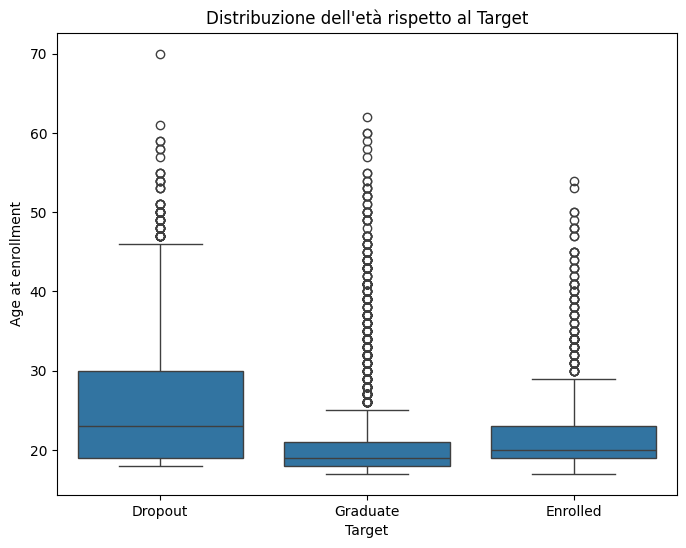

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Target', y='Age at enrollment', data=df)
plt.title('Distribuzione dell\'età rispetto al Target')
plt.show()

#### Generiamo un grafico di dispersione per il controllo degli outlier
Generando un grafico di dispersione per studiare la distribuzione dei voti tra 1º e 2º semestre e l'individuazione di eventuali outlier. Il grafico evidenzia la presenza di outlier significativi, in particolare studenti che pur avendo ottenuto buoni risultati nel primo semestre presentano una valutazione pari a zero nel secondo. La colorazione per Target conferma che questi casi appartengono quasi esclusivamente alla classe Dropout, indicando che un improvviso arresto o abbassamento nelle valutazioni è il segnale più forte di un imminente abbandono

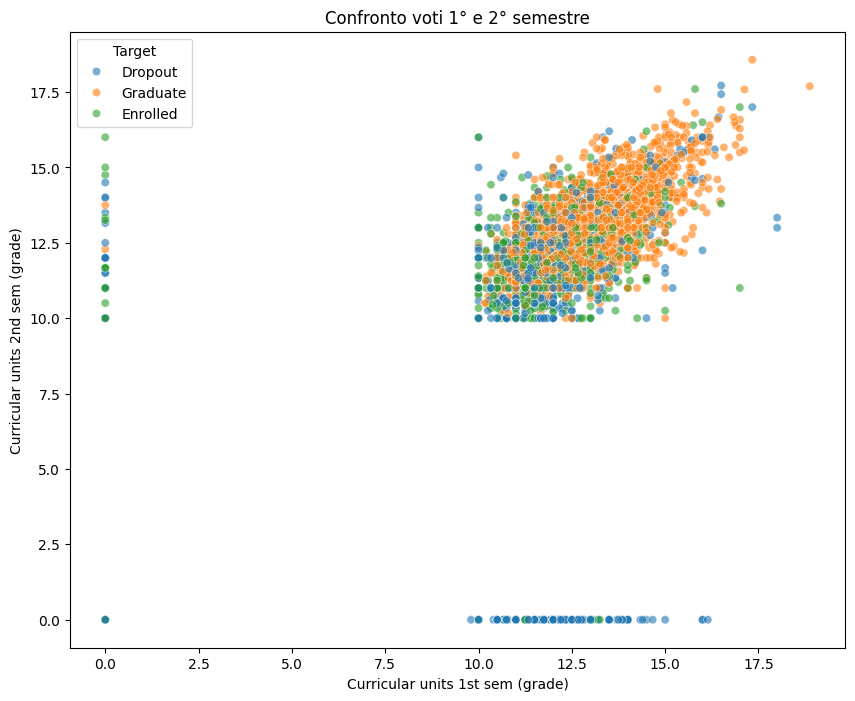

In [7]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Curricular units 1st sem (grade)', 
                y='Curricular units 2nd sem (grade)', 
                hue='Target',
                data=df,
                alpha=0.6)
plt.title("Confronto voti 1° e 2° semestre")
plt.show()

### Controlliamo la varianza delle tabelle "Curricular units (credited)" per verificarne l'effettiva utilità informativa
Possiamo notare dalle percentuali che quasi il 90% dei record presenta un valore pari a zero. Questa scarsa varianza indica che la variabile non è in grado di distinguere significativamente i diversi profili degli studenti. Pertanto per ottimizzare il dataset e ridurre il rumore statistico queste feature verranno rimosse nella successiva fase di cleaning

In [8]:
# Analizziamo la percentuale di zeri per confermare la scarsa varianza
for col in ['Curricular units 1st sem (credited)', 'Curricular units 2nd sem (credited)']:
    conta_zeri = (df[col] == 0).sum()
    percentuale = (conta_zeri / len(df)) * 100
    print(f"{col}: {conta_zeri} valori a zero ({percentuale:.2f}%)")

Curricular units 1st sem (credited): 3847 valori a zero (86.96%)
Curricular units 2nd sem (credited): 3894 valori a zero (88.02%)



### Conclusioni e Strategia per il Data Cleaning

L'analisi ha delineato con chiarezza quali sono i fattori determinanti per il successo accademico e quali invece rappresentano solo "rumore" statistico. Ecco i punti su cui baseremo la pulizia del dataset:

1.  **Definizione del Target:**
    La classe *Enrolled* rappresenta uno stato di incertezza che non aiuta la previsione. Per costruire un modello solido, limiteremo l'analisi a una classificazione binaria netta: **Dropout** vs **Graduate**.

2.  **Performance Accademica (Qualità e Quantità):**
    I voti del secondo semestre sono il predittore più forte. Manterremo sia la media voti (*Grade*) sia il numero di esami iscritti (*Enrolled*) e approvati (*Approved*).
    * *Motivazione:* Tenere queste variabili insieme permette al modello di capire l'**efficienza** dello studente (ovvero: quanti esami supera rispetto a quelli che ha in programma), un segnale spesso più potente del semplice voto.

3.  **Pulizia delle Feature:**
    Per alleggerire il modello e migliorarne la precisione, nel prossimo notebook rimuoveremo:
    * **Dati a bassa varianza:** *Curricular units credited* e *without evaluations* (che sono quasi sempre zero).
    * **Ridondanze:** *Nacionality* (già spiegata da *International*).
    * **Dati non rilevanti:** Le variabili macroeconomiche (*GDP, Inflation, Unemployment*) e anagrafiche deboli (*Marital status, Application order*), che hanno mostrato correlazioni nulle con il successo dello studente.

Procediamo ora con il notebook `data_cleaning.ipynb` per applicare tecnicamente queste trasformazioni e preparare il dataset finale
